# WD+WD Figure 3 — ΔM vs Δt_cool

Reproduces Figure 3 from Heintz et al. (2024, WD+WD paper):  
mass difference vs cooling age difference for wide WD+WD pairs,  
split by spectral type combination, testing consistency with a monotonic IFMR.

**Convention (Heintz)**: WD1 is the *more massive* star (M₁ ≥ M₂), so ΔM = M₁ − M₂ ≥ 0 always.  
A monotonic IFMR predicts Δt_cool = t_cool,1 − t_cool,2 > 0 (more massive WD had a shorter-lived  
progenitor → longer cooling age for the same total age).  
**Inconsistent** = 1σ inconsistent with τ_c1 > τ_c2, i.e. Δt_cool + σ < 0.

Requires `ages.pqt` produced by `stitch.py` (includes `SpType` and `pop_type` columns).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('stefan.mplstyle')

## Load data

In [2]:
# WD ages with SpType from stitch.py output
ages = pd.read_parquet('../widebinaries/data/ages.pqt')

print(f'WDs in sample: {len(ages)}')
print(f'With SpType: {ages["SpType"].notna().sum()}')
print(ages['SpType'].value_counts().head(10))

WDs in sample: 9477
With SpType: 9269
SpType
DA     7033
DA:     691
DB      518
DC      400
DC:     360
DZ       68
DQ       60
DB:      56
DZ:      49
DQ:      22
Name: count, dtype: int64


In [3]:
# El-Badry wide binary catalog — WD+WD pairs only, high-confidence
wb = pd.read_parquet('/home/arseneau/observational/catalogs/elbadry_widebinary.pqt')
wdwd = wb[(wb['binary_type'] == b'WDWD') & (wb['R_chance_align'] < 0.1)].copy()
print(f'WD+WD pairs (R_chance_align < 0.1): {len(wdwd)}')

s = set(ages['sourceid'])
mask = wdwd['source_id1'].isin(s) & wdwd['source_id2'].isin(s)
wdwd = wdwd[mask].copy()
print(f'WD+WD pairs with both in our sample: {len(wdwd)}')

WD+WD pairs (R_chance_align < 0.1): 1390
WD+WD pairs with both in our sample: 500


## Build pair table

In [4]:
age_cols = ['sourceid', 'mass_best', 'teff_best',
            'log_age_cool', 'log_age_cool_hi', 'log_age_cool_lo',
            'log_age',      'log_age_hi',      'log_age_lo',
            'SpType']

def merge_component(wdwd_df, id_col, suffix):
    return wdwd_df.merge(
        ages[age_cols].rename(columns={c: f'{c}{suffix}' for c in age_cols if c != 'sourceid'}),
        left_on=id_col, right_on='sourceid', how='left'
    ).drop('sourceid', axis=1)

pairs = merge_component(wdwd[['source_id1', 'source_id2', 'R_chance_align']].copy(), 'source_id1', '_1')
pairs = merge_component(pairs, 'source_id2', '_2')

print(f'Pairs: {len(pairs)}')
print(f'Both have log_age_cool: {pairs[["log_age_cool_1","log_age_cool_2"]].notna().all(axis=1).sum()}')
print(f'Both have log_age:      {pairs[["log_age_1","log_age_2"]].notna().all(axis=1).sum()}')

Pairs: 500
Both have log_age_cool: 500
Both have log_age:      156


In [5]:
# Enforce Heintz convention: WD1 = more massive star (M1 >= M2)
# Swap all _1/_2 columns for rows where mass_best_2 > mass_best_1
swap_cols = [c.replace('_1', '') for c in pairs.columns if c.endswith('_1')]
needs_swap = pairs['mass_best_2'] > pairs['mass_best_1']
print(f'Pairs swapped to enforce M1 >= M2: {needs_swap.sum()}')

for col in swap_cols:
    tmp = pairs.loc[needs_swap, f'{col}_1'].copy()
    pairs.loc[needs_swap, f'{col}_1'] = pairs.loc[needs_swap, f'{col}_2']
    pairs.loc[needs_swap, f'{col}_2'] = tmp

Pairs swapped to enforce M1 >= M2: 241


In [6]:
def log_to_gyr(log_age_yr):
    """Convert log10(yr) to Gyr."""
    return 10**(log_age_yr - 9)

for i in ['1', '2']:
    for base in ['log_age_cool', 'log_age']:
        pairs[f't_{base}_{i}']    = log_to_gyr(pairs[f'{base}_{i}'])
        pairs[f't_{base}_hi_{i}'] = log_to_gyr(pairs[f'{base}_hi_{i}'])
        pairs[f't_{base}_lo_{i}'] = log_to_gyr(pairs[f'{base}_lo_{i}'])
        pairs[f'e_t_{base}_{i}']  = (pairs[f't_{base}_hi_{i}'] - pairs[f't_{base}_lo_{i}']) / 2

# dM >= 0 by construction; positive differences consistent with monotonic IFMR
pairs['dM'] = pairs['mass_best_1'] - pairs['mass_best_2']

for base in ['log_age_cool', 'log_age']:
    pairs[f'd_{base}']   = pairs[f't_{base}_1']   - pairs[f't_{base}_2']
    pairs[f'e_d_{base}'] = np.sqrt(pairs[f'e_t_{base}_1']**2 + pairs[f'e_t_{base}_2']**2)

# Aliases used in the plotting cells
pairs['dtcool']   = pairs['d_log_age_cool']
pairs['e_dtcool'] = pairs['e_d_log_age_cool']
pairs['dtot']     = pairs['d_log_age']
pairs['e_dtot']   = pairs['e_d_log_age']

valid_cool = pairs[['dM', 'dtcool', 'e_dtcool']].notna().all(axis=1)
valid_tot  = pairs[['dM', 'dtot',   'e_dtot'  ]].notna().all(axis=1)
print(f'Pairs with finite dM and dtcool: {valid_cool.sum()}')
print(f'Pairs with finite dM and dtot:   {valid_tot.sum()}')
assert (pairs.loc[valid_cool, 'dM'] >= 0).all(), 'dM should be non-negative after swap'

Pairs with finite dM and dtcool: 500
Pairs with finite dM and dtot:   156


## Spectral type classification

In [7]:
def stype_flags(stype_series):
    """Return (is_DA, is_DB, is_DC) boolean Series."""
    st = stype_series.fillna('').str.upper().str.replace(':', '', regex=False).str.strip()
    is_DA = st.str.startswith('DA') & ~st.str.startswith('DAB')
    is_DB = st.str.startswith('DB') | st.str.startswith('DAB') | st.str.startswith('DBA')
    is_DC = st.str.startswith('DC')
    return is_DA, is_DB, is_DC

is_DA1, is_DB1, is_DC1 = stype_flags(pairs['SpType_1'])  # more massive
is_DA2, is_DB2, is_DC2 = stype_flags(pairs['SpType_2'])  # less massive

panel_masks = {
    'DA+DA': is_DA1  &  is_DA2,
    'DA+DB': (is_DA1 &  is_DB2) | (is_DB1 &  is_DA2),
    'DA+DC': (is_DA1 &  is_DC2) | (is_DC1 &  is_DA2),
    'DC+DC':  is_DC1 &  is_DC2,
}

for label, mask in panel_masks.items():
    n = (mask & valid_cool).sum()
    print(f'{label}: {n} pairs with finite cooling ages')

DA+DA: 351 pairs with finite cooling ages
DA+DB: 25 pairs with finite cooling ages
DA+DC: 80 pairs with finite cooling ages
DC+DC: 11 pairs with finite cooling ages


## Figure 3

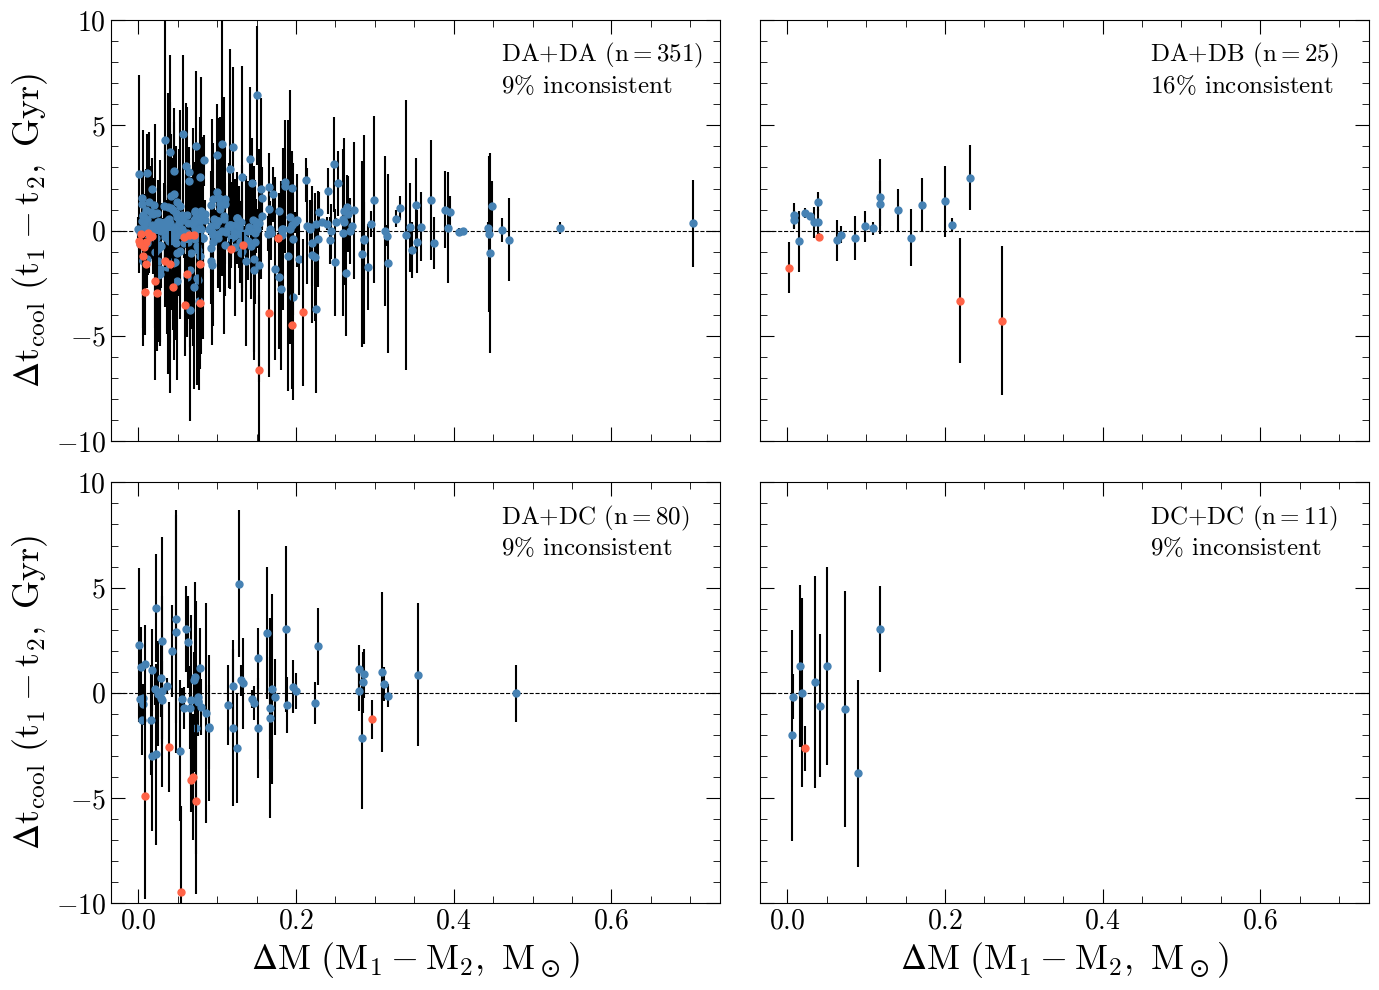

In [8]:
def inconsistency_stats(df, valid_mask, panel_mask, dt_col, e_dt_col, one_sided):
    """Fraction 1σ inconsistent with τ_1 > τ_2, i.e. dt + e_dt < 0."""
    sel = df[valid_mask & panel_mask]
    if len(sel) == 0:
        return 0, np.nan
    
    if not one_sided:
        inconsist = sel[dt_col] + sel[e_dt_col] < 0
    else:
        inconsist = sel[dt_col].abs() - sel[e_dt_col] > 0
    return len(sel), inconsist, inconsist.mean()


def plot_dm_dt(pairs, valid_mask, panel_masks, dt_col, e_dt_col, ylabel, one_sided=False):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
    axes = axes.flatten()

    for ax, (label, panel_mask) in zip(axes, panel_masks.items()):
        sel = pairs[valid_mask & panel_mask]
        n_tot, inconsist, f_inc = inconsistency_stats(pairs, valid_mask, panel_mask, dt_col, e_dt_col, one_sided)

        if len(sel) == 0:
            ax.text(0.5, 0.5, 'No data', transform=ax.transAxes, ha='center')
            ax.set_title(label)
            continue

        ax.errorbar(
            sel.loc[~inconsist, 'dM'], sel.loc[~inconsist, dt_col],
            yerr=sel.loc[~inconsist, e_dt_col],
            fmt='o', alpha=1, color='steelblue', ecolor='k', zorder=2,
            label='Consistent'
        )
        ax.errorbar(
            sel.loc[inconsist, 'dM'], sel.loc[inconsist, dt_col],
            yerr=sel.loc[inconsist, e_dt_col],
            fmt='o', alpha=1, color='tomato', ecolor='k', zorder=3,
            label='Inconsistent'
        )

        ax.axhline(0, color='k', lw=0.8, ls='--', zorder=1)

        ax.text(0.64, 0.95,
                f'{label} ($n = {n_tot}$)\n${100*f_inc:.0f}\\%$ inconsistent',
                transform=ax.transAxes, va='top', fontsize=18,
                bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.0))
        
        
    axes[2].set_xlabel(r'$\Delta M\ (M_1 - M_2,\ M_\odot)$')
    axes[3].set_xlabel(r'$\Delta M\ (M_1 - M_2,\ M_\odot)$')

    axes[0].set_ylabel(ylabel)
    axes[2].set_ylabel(ylabel)

    axes[0].set_ylim(-10, 10)

    plt.tight_layout()
    plt.show()


plot_dm_dt(
    pairs, valid_cool, panel_masks,
    dt_col='dtcool', e_dt_col='e_dtcool',
    ylabel=r'$\Delta t_\mathrm{cool}\ (t_1 - t_2,\ \mathrm{Gyr})$',
    one_sided=False
)

## Total age differences

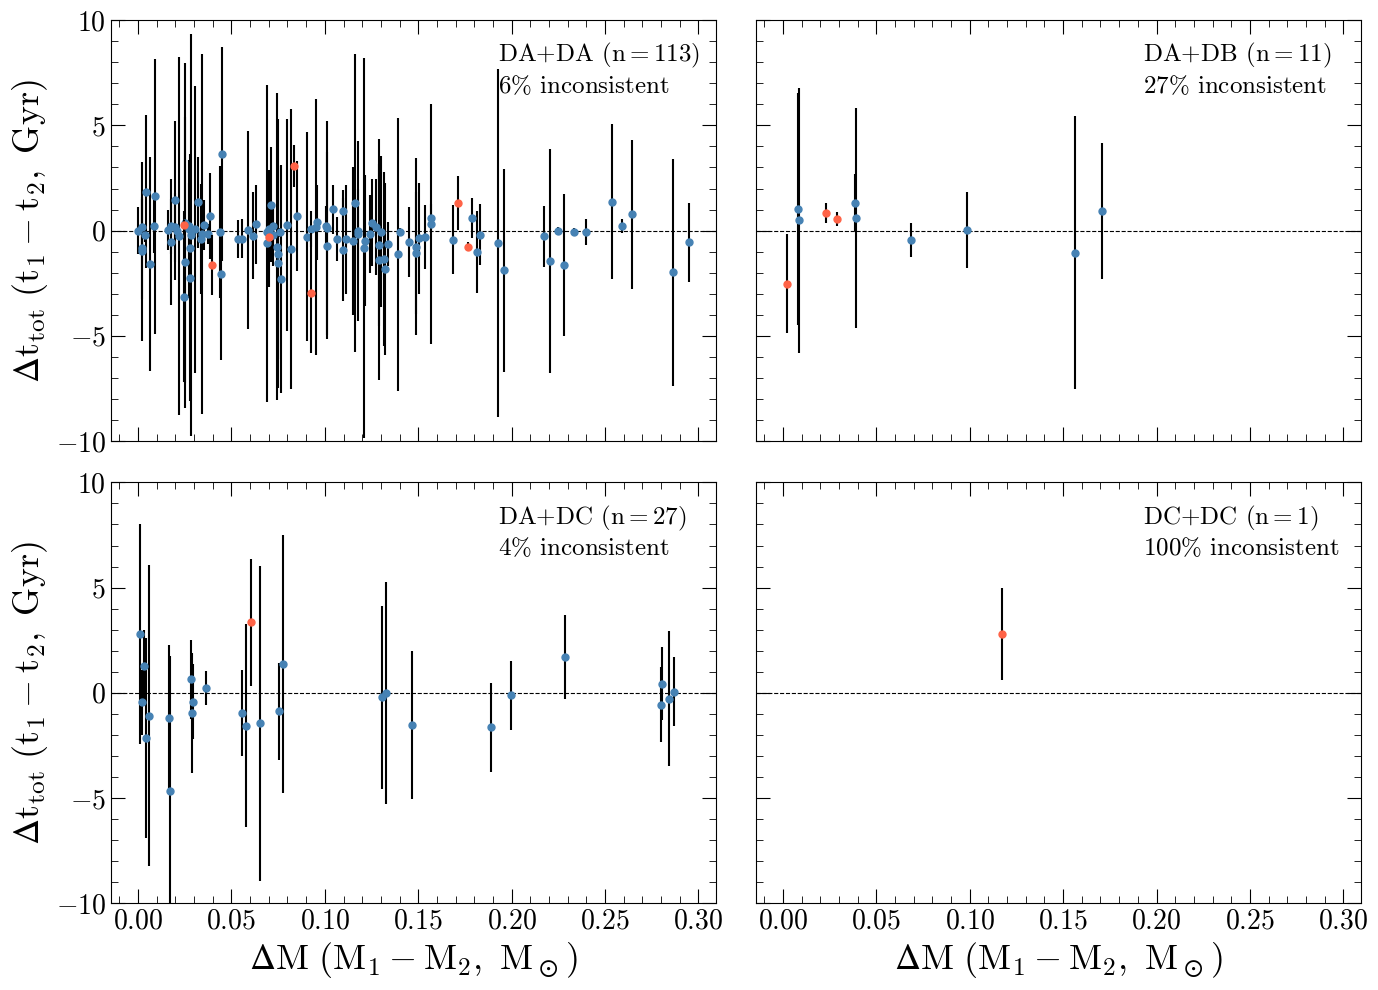

In [9]:
plot_dm_dt(
    pairs, valid_tot, panel_masks,
    dt_col='dtot', e_dt_col='e_dtot',
    ylabel=r'$\Delta t_\mathrm{tot}\ (t_1 - t_2,\ \mathrm{Gyr})$',
    one_sided=True
)

## Summary

In [10]:
print('=== Cooling age (1σ inconsistent with τ_c1 > τ_c2) ===')
for label, panel_mask in panel_masks.items():
    n, f = inconsistency_stats(pairs, valid_cool, panel_mask, 'dtcool', 'e_dtcool')
    if n > 0:
        print(f'{label:10s}  n={n:3d}  inconsistent={100*f:.0f}%')

print()
print('=== Total age (1σ inconsistent with τ_tot,1 > τ_tot,2) ===')
for label, panel_mask in panel_masks.items():
    n, f = inconsistency_stats(pairs, valid_tot, panel_mask, 'dtot', 'e_dtot')
    if n > 0:
        print(f'{label:10s}  n={n:3d}  inconsistent={100*f:.0f}%')

=== Cooling age (1σ inconsistent with τ_c1 > τ_c2) ===


TypeError: inconsistency_stats() missing 1 required positional argument: 'one_sided'